In [1]:
# 16_RCS_plus.ipynb
# Build RCS+ (physiology/labs OK + no abx escalation + no new positive cultures + no radiology worsening)

import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

# ----------------------------
# Paths (adjust if needed)
# ----------------------------
DAILY_BASE_PATH = "09_diana_daily.parquet"   # TODO: confirm your actual daily base parquet
ABX_PATH        = "13_abx_escalation_daily.parquet"
MICRO_PATH      = "15_dataset_diario_sin_nueva_infeccion.parquet"
RAD_PATH        = "15_radiology_worsening_daily.parquet"

OUT_DAILY_PATH  = "16_dataset_diario_RCS_plus.parquet"
OUT_STAY_PATH   = "16_respuesta_clinica_sostenida_RCS_plus.parquet"

# ----------------------------
# Parameters
# ----------------------------
START_DAY_IDX = 1          # exclude baseline day 0
MIN_CONSEC_DAYS = 2        # TODO: set to your N (same as in script 10)

# ----------------------------
# Helpers
# ----------------------------
def compute_first_sustained_day(df_daily: pd.DataFrame,
                               id_cols: list,
                               day_col: str,
                               start_day_idx: int,
                               min_consec_days: int):
    """
    For each stay, find the first day_idx when >= min_consec_days consecutive 1s occur in day_col,
    considering only rows with day_idx >= start_day_idx.

    Returns a stay-level dataframe with:
      - ever_flag (0/1)
      - first_day_idx (int or NaN)
    """
    df = df_daily.copy()
    df = df[df["day_idx"] >= start_day_idx].copy()

    # Ensure sorted
    df = df.sort_values(id_cols + ["day_idx"])

    out_rows = []
    for key, g in df.groupby(id_cols, sort=False):
        x = g[day_col].fillna(0).astype(int).to_numpy()
        days = g["day_idx"].to_numpy()

        first_idx = np.nan
        consec = 0
        for i, val in enumerate(x):
            consec = consec + 1 if val == 1 else 0
            if consec >= min_consec_days:
                # the first day of the run is current day minus (min_consec_days-1)
                first_idx = int(days[i - (min_consec_days - 1)])
                break

        ever = int(not np.isnan(first_idx))
        if isinstance(key, tuple):
            row = list(key)
        else:
            row = [key]
        out_rows.append(row + [ever, first_idx])

    out = pd.DataFrame(out_rows, columns=id_cols + [f"ever_{day_col}", f"{day_col}_first_day_idx"])
    return out

In [2]:
# ----------------------------
# Load data
# ----------------------------
df_daily = pd.read_parquet(DAILY_BASE_PATH).copy()

# Basic checks
required_cols = ["subject_id", "hadm_id", "icu_stay_id", "day_idx"]
missing = [c for c in required_cols if c not in df_daily.columns]
if missing:
    raise ValueError(f"Daily base is missing required columns: {missing}")

# ----------------------------
# Load and merge flags
# ----------------------------
df_abx = pd.read_parquet(ABX_PATH)[["subject_id","hadm_id","icu_stay_id","day_idx","abx_escalation_flag"]].copy()
df_micro = pd.read_parquet(MICRO_PATH)[["subject_id","hadm_id","icu_stay_id","day_idx","new_pos_culture_flag"]].copy()
df_rad = pd.read_parquet(RAD_PATH)[["subject_id","hadm_id","icu_stay_id","day_idx","rad_worsening_flag"]].copy()

df_daily = df_daily.merge(df_abx, on=required_cols, how="left")
df_daily = df_daily.merge(df_micro, on=required_cols, how="left")
df_daily = df_daily.merge(df_rad, on=required_cols, how="left")

for c in ["abx_escalation_flag","new_pos_culture_flag","rad_worsening_flag"]:
    df_daily[c] = df_daily[c].fillna(0).astype(int)

In [4]:
# ----------------------------
# Define day_good_RCS_plus
# ----------------------------
# TODO: set this to the name of your existing "good day" flag from Script 10
# Common patterns: "day_good", "day_ok", "day_good_RCS", "clinical_ok_day"
BASE_GOOD_DAY_COL = "diana_daily_ok_observed"   # TODO: adjust to your real column name

if BASE_GOOD_DAY_COL not in df_daily.columns:
    raise ValueError(
        f"Cannot find BASE_GOOD_DAY_COL='{BASE_GOOD_DAY_COL}' in daily base. "
        f"Available columns (sample): {df_daily.columns.tolist()[:60]}"
    )

df_daily["day_good_RCS_plus"] = (
    (df_daily[BASE_GOOD_DAY_COL].fillna(0).astype(int) == 1) &
    (df_daily["abx_escalation_flag"] == 0) &
    (df_daily["new_pos_culture_flag"] == 0) &
    (df_daily["rad_worsening_flag"] == 0)
).astype(int)

# Save daily enriched dataset
df_daily.to_parquet(OUT_DAILY_PATH, index=False)

# ----------------------------
# Compute sustained response at stay level
# ----------------------------
id_cols = ["subject_id","hadm_id","icu_stay_id"]

df_stay = compute_first_sustained_day(
    df_daily=df_daily,
    id_cols=id_cols,
    day_col="day_good_RCS_plus",
    start_day_idx=START_DAY_IDX,
    min_consec_days=MIN_CONSEC_DAYS
)

# Rename outputs to match your conventions
df_stay = df_stay.rename(columns={
    "ever_day_good_RCS_plus": "ever_rcs_plus",
    "day_good_RCS_plus_first_day_idx": "rcs_plus_day_idx"
})

df_stay.to_parquet(OUT_STAY_PATH, index=False)

# ----------------------------
# QC
# ----------------------------
print("Daily dataset:", df_daily.shape)
print("Stay-level RCS+:", df_stay.shape)
print("Pct ever_rcs_plus:", df_stay["ever_rcs_plus"].mean())
print("rcs_plus_day_idx (head):")
print(df_stay["rcs_plus_day_idx"].dropna().astype(int).head(20).to_list())

print("\nBy day_idx: share of day_good_RCS_plus")
print(df_daily.groupby("day_idx")["day_good_RCS_plus"].mean().head(15))

Daily dataset: (65957699, 32)
Stay-level RCS+: (18629, 5)
Pct ever_rcs_plus: 0.5941274357185035
rcs_plus_day_idx (head):
[1, 7, 4, 1, 1, 1, 2, 3, 1, 1, 1, 3, 1, 1, 5, 5, 1, 1, 1, 1]

By day_idx: share of day_good_RCS_plus
day_idx
0     0.224370
1     0.271280
2     0.268198
3     0.292559
4     0.293288
5     0.293418
6     0.284837
7     0.259100
8     0.282753
9     0.266875
10    0.319001
11    0.301062
12    0.403496
13    0.444272
14    0.387336
Name: day_good_RCS_plus, dtype: float64


In [5]:
df_stay["ever_rcs_plus"].value_counts(normalize=True)

ever_rcs_plus
1    0.594127
0    0.405873
Name: proportion, dtype: float64

In [6]:
df_stay["rcs_plus_day_idx"].describe()

count    11068.000000
mean         3.335110
std          4.086001
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         30.000000
Name: rcs_plus_day_idx, dtype: float64

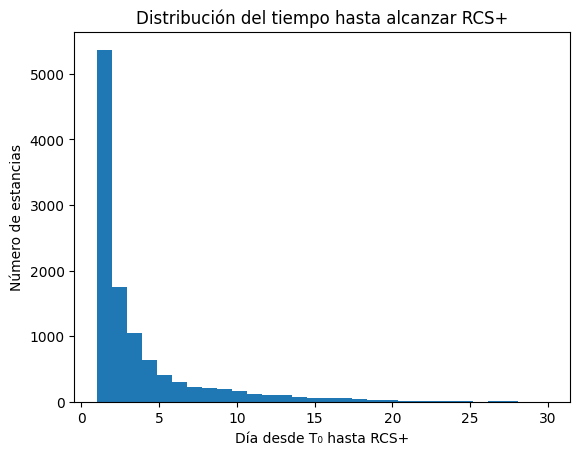

In [7]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df_stay["rcs_plus_day_idx"].dropna(), bins=30)
plt.xlabel("Día desde T₀ hasta RCS+")
plt.ylabel("Número de estancias")
plt.title("Distribución del tiempo hasta alcanzar RCS+")
plt.show()

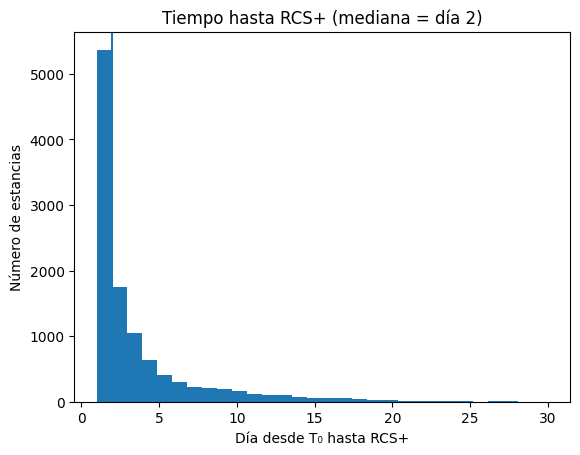

In [8]:
median_day = df_stay["rcs_plus_day_idx"].median()

plt.figure()
plt.hist(df_stay["rcs_plus_day_idx"].dropna(), bins=30)
plt.axvline(median_day)
plt.xlabel("Día desde T₀ hasta RCS+")
plt.ylabel("Número de estancias")
plt.title(f"Tiempo hasta RCS+ (mediana = día {int(median_day)})")
plt.show()